<a href="https://colab.research.google.com/github/iweam/genai-bootcamp/blob/main/W2S1_Lab_Tokens_and_Temperature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Tokens, Generation & Temperature</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 2 · Session 1 — Inside Large Language Models</div>
    </div>
    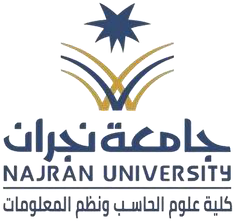
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENL track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Turn text into <b>tokens</b> and compare English vs Arabic token counts.</li>
<li style="margin:5px 0;">Load an open LLM and <b>generate text</b> with the Hugging Face library.</li>
<li style="margin:5px 0;">See how <b>temperature</b> and <b>top-p</b> change the output.</li>
<li style="margin:5px 0;">(Optional) Call a free hosted model and compare.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Everything here also runs on CPU, just slower.</div></div>

### Setup
Colab already includes PyTorch. We just add the latest Transformers library.

In [1]:
# One-time setup (takes ~30 seconds)
!pip -q install -U "transformers>=4.44" accelerate
print("Setup complete — now run the cells below in order.")

Setup complete — now run the cells below in order.


## Part 1 — Tokenization

A model never sees letters or words; it sees **tokens** (chunks of text mapped to numbers). Let's load a tokenizer and look.

In [2]:
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # open & ungated — no login or token needed
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
print("Tokenizer loaded for:", MODEL_ID)
print("Vocabulary size:", tokenizer.vocab_size, "tokens")

Tokenizer loaded for: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151643 tokens


In [3]:
text = "Large language models are changing the future!"
ids = tokenizer.encode(text)
tokens = tokenizer.convert_ids_to_tokens(ids)

print("Text:     ", text)
print("Tokens:   ", tokens)
print("Token IDs:", ids)
print(f"\n{len(text)} characters  ->  {len(ids)} tokens")
print(f"Ratio: {len(text)/len(ids):.1f} characters per token")

Text:      Large language models are changing the future!
Tokens:    ['Large', 'Ġlanguage', 'Ġmodels', 'Ġare', 'Ġchanging', 'Ġthe', 'Ġfuture', '!']
Token IDs: [34253, 4128, 4119, 525, 10018, 279, 3853, 0]

46 characters  ->  8 tokens
Ratio: 5.8 characters per token


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ The ~4-characters rule</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">In English, <b>1 token ≈ 4 characters ≈ ¾ of a word</b>. So ~100 tokens ≈ 75 words. This is the rule of thumb from the slides — now you can verify it yourself.</div></div>

### Does the language matter? (English vs Arabic)

Most models are trained mostly on English, so other languages often need **more tokens** for the same meaning.

In [4]:
def token_report(label, text):
    n_tok = len(tokenizer.encode(text))
    n_chr, n_wrd = len(text), len(text.split())
    print(f"{label:9s} | {n_chr:3d} chars | {n_wrd:2d} words | {n_tok:3d} tokens "
          f"| {n_chr/n_tok:.1f} chars/token")

print("Same meaning, two languages:\n")
token_report("English", "Be the change you want.")
token_report("Arabic",  "كن أنت التغيير الذي تريده.")

Same meaning, two languages:

English   |  23 chars |  5 words |   6 tokens | 3.8 chars/token
Arabic    |  26 chars |  5 words |  11 tokens | 2.4 chars/token


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Tokenization sits in the <b>Core ML & AI</b> domain. Know that token count (not word count) drives cost, latency and the context limit — and that it varies by language and by tokenizer.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Put your own sentence below — try it in English <b>and</b> Arabic and compare the token counts.</div></div>

In [5]:
# ✍️ Edit the text, then run
my_text = "Coding is today's language of creativity."
ids = tokenizer.encode(my_text)
print(f"{len(my_text)} characters -> {len(ids)} tokens")
print("Rough word estimate (tokens x 0.75):", round(len(ids)*0.75))

41 characters -> 8 tokens
Rough word estimate (tokens x 0.75): 6


## Part 2 — Load the model and generate text

Now we load the full model. `Qwen2.5-1.5B-Instruct` is small enough for the free T4 GPU (~3 GB).

In [6]:
import torch
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # half precision — fits the T4
    device_map="auto",           # use the GPU if one is available
)
print("Model loaded on:", next(model.parameters()).device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded on: cuda:0


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ If this is very slow</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">You are probably on CPU. Switch to a GPU runtime (see the setup box at the top) and re-run.</div></div>

### A helper to chat with the model
Instruct models expect a **chat template**. This helper wraps it so we can just pass a prompt.

In [7]:
def chat(prompt, max_new_tokens=120, **gen_kwargs):
    messages = [{"role": "user", "content": prompt}]
    # apply_chat_template returns a dictionary-like BatchEncoding object
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    # We unpack the dictionary using **inputs so the model gets input_ids and attention_mask
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         pad_token_id=tokenizer.eos_token_id, **gen_kwargs)

    # We use inputs['input_ids'] to find the length of the prompt to slice the output
    prompt_length = inputs['input_ids'].shape[1]
    return tokenizer.decode(out[0][prompt_length:], skip_special_tokens=True)

print(chat("In one sentence, How is AI impacting our daily lives?"))

Artificial Intelligence (AI) is transforming various aspects of daily life, from personal technology and healthcare to transportation and manufacturing, making it easier for people to live more efficiently and comfortably.


## Part 3 — Decoding: temperature & top-p

Same model, same prompt — the **decoding settings** decide how the next token is chosen.

### Temperature 0 → deterministic (greedy)
The model always picks the most likely token, so you get the **same answer every time**.

In [8]:
prompt = "Give me a creative name for a bookstore in Najran."
for i in range(3):
    print(f"Run {i+1}:", chat(prompt, max_new_tokens=20, do_sample=False))

Run 1: "Words of Najran"
Run 2: "Words of Najran"
Run 3: "Words of Najran"


### High temperature → creative (sampling)
Now the model samples, so each run is **different**.

In [9]:
from transformers import set_seed
for i in range(3):
    set_seed(i)   # different seed each run -> see the variety
    print(f"Run {i+1}:", chat(prompt, max_new_tokens=20,
                              do_sample=True, temperature=1.2, top_p=0.95))

Run 1: Book Haven Oasis
Run 2: Certainly! How about "Book Haven Najraan"? It suggests a cozy, inviting atmosphere where literature
Run 3: Al-Fushia Store


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Rule of thumb</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Use <b>temperature 0</b> for facts, code and classification (you want one correct answer). Use <b>~0.7–1.2 with top-p ~0.9</b> for brainstorming and creative writing.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Compare settings on two tasks: a <b>factual</b> question (temperature 0 is best) and a <b>creative</b> one (try 0.3 vs 1.2).</div></div>

In [10]:
# 1) Factual — greedy is reliable
print("Factual :", chat("How many days are in year?", max_new_tokens=10, do_sample=False))

# 2) Creative — try changing temperature to 0.3, then 1.2, and re-run
print("Creative:", chat("Write a description for a student majoring in Information Systems.",
                        max_new_tokens=25, do_sample=True, temperature=1.2, top_p=0.95))

Factual : A common year has 365 days and
Creative: A degree in Information Systems equips students with the skills and knowledge necessary to analyze, design, implement and manage computer systems,


## Part 4 — (Optional) Call a free hosted model

Want to compare your small open model with a frontier-scale one? Google AI Studio has a **free tier**.

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Optional — needs a free key</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">1) Get a free key at <b>aistudio.google.com/apikey</b>.  2) In Colab, click the 🔑 (left sidebar) and add a secret named <b>GOOGLE_API_KEY</b>.  Then run the cell. Skip this part if you prefer to stay fully offline.</div></div>

In [13]:
!pip -q install -U google-genai

from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))

response = client.models.generate_content(
    model="models/gemini-3.5-flash",
    contents="In one sentence, what is a large language model?"
)

print(response.text)

A large language model is a type of artificial intelligence trained on vast amounts of text data to understand, process, and generate human-like language.


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">Text → <b>tokens</b> → numbers; token count (not words) drives cost & the context limit.</li>
<li style="margin:5px 0;">Tokenization depends on the language — Arabic used more tokens than English.</li>
<li style="margin:5px 0;">An instruct model generates via a <b>chat template</b>, one token at a time.</li>
<li style="margin:5px 0;"><b>Temperature 0</b> is deterministic; higher temperature + top-p adds creativity.</li>
<li style="margin:5px 0;">You can run a useful LLM on a <b>free Colab GPU</b> with no API key.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). Next session: building real text pipelines with Hugging Face.